# Data Analytics Project Work: Gas Turbine Emission & Energy Analysis
**Course:** Data Analytics (and Data Driven Decision) — University of L'Aquila  
**Dataset:** Gas Turbine CO and NOx Emission Data Set (2011–2015)  

---
## Project Guidelines Structure
1. **Description of the dataset**
2. **Data cleaning (if needed)**
3. **Exploratory analysis**
4. **Main analysis: objective and methods adopted**
5. **Preview / summary of the results**
6. **Detailed results**
7. **Conclusions**

---

## 0. Setup and Environment
Importing standard libraries required for data manipulation, analysis, and visualization.

In [58]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("Environment initialized successfully.")

Environment initialized successfully.


## 1. Description of the Dataset

### 1.1 Context & Industrial Background
The dataset comprises **36,733 hourly aggregated records** of 11 sensor measurements collected from an operational gas turbine located in the north-western region of Turkey across five consecutive years (**2011 to 2015**).

The source files do not contain exact timestamps. Their rows are already sorted chronologically, so the `year` column is assigned from each file name (`gt_2011.csv` through `gt_2015.csv`).

The project has two connected objectives:
- **Energy-yield prediction:** predict Turbine Energy Yield (`TEY`) from operating and ambient measurements.
- **Emissions analysis and prediction:** study and model Carbon Monoxide (`CO`) and Nitrogen Oxides (`NOX`).

For predictive models, the variables are separated into:
- **Predictors:** `AT`, `AP`, `AH`, `AFDP`, `GTEP`, `TIT`, `TAT`, `CDP`.
- **Targets:** `TEY`, `CO`, `NOX`.

### 1.2 Variable Definitions & Engineering Roles

| Variable | Symbol | Unit | Category | Physical Role / Interpretation |
| :--- | :--- | :--- | :--- | :--- |
| Ambient Temperature | `AT` | °C | Ambient | Ambient intake air temperature; directly influences air density and mass flow rate. |
| Ambient Pressure | `AP` | mbar | Ambient | Atmospheric barometric pressure surrounding the power plant. |
| Ambient Humidity | `AH` | % | Ambient | Intake air relative humidity; influences flame temperature and moisture content. |
| Air Filter Diff. Pressure | `AFDP` | mbar | Turbine | Pressure drop across the intake air filter (indicator of filter clogging). |
| Gas Turbine Exhaust Pressure | `GTEP` | mbar | Turbine | Static exhaust backpressure in the expansion duct. |
| Turbine Inlet Temperature | `TIT` | °C | Turbine | Firing temperature of hot combustion gas entering the expander. |
| Turbine After Temperature | `TAT` | °C | Turbine | Exhaust gas temperature downstream of the expander. |
| Compressor Discharge Pressure | `CDP` | mbar | Turbine | Pressure of compressed air exiting compressor stage. |
| Turbine Energy Yield | `TEY` | MWh | Output | Hourly net electrical energy output generated by the unit. |
| Carbon Monoxide | `CO` | mg/m³ | Emission | Measured flue gas CO concentration (incomplete combustion). |
| Nitrogen Oxides | `NOX` | mg/m³ | Emission | Measured flue gas NOx concentration (thermal oxidation). |

### 1.3 Data Ingestion & Concatenation

In [59]:
data_dir = os.path.join("data", "gas+turbine+co+and+nox+emission+data+set")
years = [2011, 2012, 2013, 2014, 2015]

dfs = []
for y in years:
    fpath = os.path.join(data_dir, f"gt_{y}.csv")
    df_y = pd.read_csv(fpath)
    df_y['year'] = y
    dfs.append(df_y)
    print(f"Year {y}: {df_y.shape[0]:,d} observations")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nTotal Combined Records: {df_raw.shape[0]:,d} rows × {df_raw.shape[1]} columns")
df_raw.head()

Year 2011: 7,411 observations
Year 2012: 7,628 observations
Year 2013: 7,152 observations
Year 2014: 7,158 observations
Year 2015: 7,384 observations

Total Combined Records: 36,733 rows × 12 columns


,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX,year
0,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,0.32663,81.952,2011
1,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,0.44784,82.377,2011
2,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,0.45144,83.776,2011
3,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,0.23107,82.505,2011
4,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,0.26747,82.028,2011


### 1.4 Initial Dataset Verification & Summary Statistics

In [60]:
sensor_cols = ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP', 'CO', 'NOX']

# Summary statistics
stats_table = df_raw[sensor_cols].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
stats_table.columns = ['Count', 'Mean', 'Std Dev', 'Min', 'Q1 (25%)', 'Median (50%)', 'Q3 (75%)', 'Max']
stats_table.round(2)

,Count,Mean,Std Dev,Min,Q1 (25%),Median (50%),Q3 (75%),Max
AT,36733.0,17.71,7.45,-6.23,11.78,17.80,23.66,37.10
AP,36733.0,1013.07,6.46,985.85,1008.80,1012.60,1017.00,1036.60
AH,36733.0,77.87,14.46,24.08,68.19,80.47,89.38,100.20
AFDP,36733.0,3.93,0.77,2.09,3.36,3.94,4.38,7.61
GTEP,36733.0,25.56,4.20,17.70,23.13,25.10,29.06,40.72
TIT,36733.0,1081.43,17.54,1000.80,1071.80,1085.90,1097.00,1100.90
TAT,36733.0,546.16,6.84,511.04,544.72,549.88,550.04,550.61
TEY,36733.0,133.51,15.62,100.02,124.45,133.73,144.08,179.50
CDP,36733.0,12.06,1.09,9.85,11.44,11.96,12.86,15.16
CO,36733.0,2.37,2.26,0.00,1.18,1.71,2.84,44.10


## 2. Data Cleaning, Quality Validation & Preprocessing

Following the methodology taught in **Lecture 4 & Exercise 4.2**, we perform structured data quality validation:
1. **Missing values verification** (`isnull().sum()`)
2. **Duplicate detection and removal**
3. **Physical range and sanity validation**
4. **Outlier detection via $\sigma$-clipping technique** with robust dispersion estimation:  
   $$\hat{\sigma} = \frac{\text{IQR}}{1.35} = \frac{Q_3 - Q_1}{1.35}$$
   using the median as the location center to prevent outlier distortion.
5. **Chronological dataset partitioning** into Training (2011–2013) and Testing (2014–2015) sets.
6. **Standardization (Z-score normalization)**:  
   $$z = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}$$

### 2.1 Missing Values and Duplicates Check

Missing values are checked across all sensor measurements. Two duplicate counts are reported: completely identical rows and repeated sensor profiles. The cleaning step removes repeated sensor profiles while preserving their first chronological occurrence; this treats identical measurements as duplicate observations even if their file/year metadata differs.

In [61]:
# 1. Missing Values
null_counts = df_raw[sensor_cols].isnull().sum()
print("=== Missing Values per Feature ===")
print(null_counts)
assert null_counts.sum() == 0, "Unexpected null values detected!"

# 2. Duplicate Rows
full_dup_count = df_raw.duplicated().sum()
sensor_dup_count = df_raw[sensor_cols].duplicated().sum()
print(f"\nDuplicate complete rows detected: {full_dup_count}")
print(f"Duplicate sensor profiles detected: {sensor_dup_count}")

# Remove repeated sensor profiles, preserving the first occurrence
df_clean = df_raw.drop_duplicates(subset=sensor_cols).copy().reset_index(drop=True)
print(f"Cleaned dataset size: {df_clean.shape[0]:,d} observations (removed {sensor_dup_count} sensor-profile duplicates)")

# Verify the cleaned dataset before continuing
assert df_clean.shape[1] == df_raw.shape[1]
assert df_clean[sensor_cols].isnull().sum().sum() == 0
assert df_clean[sensor_cols].duplicated().sum() == 0
assert len(df_clean) == len(df_raw) - sensor_dup_count

# 3. Physical range and sanity validation
sanity_checks = pd.Series({
    'AT': df_clean['AT'].between(-10, 45).all(),
    'AP': (df_clean['AP'] > 0).all(),
    'AH': df_clean['AH'].between(0, 105).all(),
    'AFDP': (df_clean['AFDP'] > 0).all(),
    'GTEP': (df_clean['GTEP'] > 0).all(),
    'TIT': df_clean['TIT'].between(900, 1150).all(),
    'TAT': df_clean['TAT'].between(450, 575).all(),
    'TEY': (df_clean['TEY'] >= 0).all(),
    'CDP': (df_clean['CDP'] > 0).all(),
    'CO': (df_clean['CO'] >= 0).all(),
    'NOX': (df_clean['NOX'] >= 0).all()
}, name='Within Plausible Physical Range')

assert sanity_checks.all(), "Values outside plausible physical ranges detected."
print("\nPhysical range and sanity validation passed.")
sanity_checks.to_frame()

=== Missing Values per Feature ===
AT      0
AP      0
AH      0
AFDP    0
GTEP    0
TIT     0
TAT     0
TEY     0
CDP     0
CO      0
NOX     0
dtype: int64

Duplicate complete rows detected: 7
Duplicate sensor profiles detected: 7
Cleaned dataset size: 36,726 observations (removed 7 sensor-profile duplicates)

Physical range and sanity validation passed.


,Within Plausible Physical Range
AT,True
AP,True
AH,True
AFDP,True
GTEP,True
TIT,True
TAT,True
TEY,True
CDP,True
CO,True


### 2.2 Outlier Analysis via $\sigma$-Clipping (Course Method)
The standard deviation $\sigma$ is highly sensitive to extreme observations. As taught in class, we use the rank-based interquartile range (IQR) to estimate $\hat{\sigma} = \text{IQR} / 1.35$ and inspect the data within $[\text{Median} - 5\hat{\sigma},\; \text{Median} + 5\hat{\sigma}]$.

The thresholds are estimated descriptively from the complete cleaned dataset before the chronological split. They are not used to remove, replace, or modify observations. The observations outside the limits are only counted and reported; in an industrial dataset, an extreme value may represent a real transient operating condition rather than a measurement error.

In [62]:
sigma_records = []
for col in sensor_cols:
    q1, med, q3 = np.percentile(df_clean[col], [25, 50, 75])
    iqr = q3 - q1
    sigma_hat = iqr / 1.35
    lower_bound = med - 5 * sigma_hat
    upper_bound = med + 5 * sigma_hat
    
    outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    
    sigma_records.append({
        'Variable': col,
        'Median': round(med, 2),
        'IQR': round(iqr, 2),
        'Estimated sigma_hat': round(sigma_hat, 2),
        'Lower 5-sigma Bound': round(lower_bound, 2),
        'Upper 5-sigma Bound': round(upper_bound, 2),
        'Outliers Count (5-sigma)': outliers,
        'Outliers %': f"{(outliers / len(df_clean))*100:.2f}%"
    })

df_sigma_table = pd.DataFrame(sigma_records)
df_sigma_table

,Variable,Median,IQR,Estimated sigma_hat,Lower 5-sigma Bound,Upper 5-sigma Bound,Outliers Count (5-sigma),Outliers %
0,AT,17.80,11.88,8.80,-26.22,61.82,0,0.00%
1,AP,1012.60,8.20,6.07,982.23,1042.97,0,0.00%
2,AH,80.47,21.19,15.70,1.98,158.95,0,0.00%
3,AFDP,3.94,1.02,0.76,0.15,7.72,0,0.00%
4,GTEP,25.10,5.93,4.39,3.14,47.07,0,0.00%
5,TIT,1085.90,25.20,18.67,992.57,1179.23,0,0.00%
6,TAT,549.88,5.32,3.94,530.18,569.58,1942,5.29%
7,TEY,133.73,19.63,14.54,61.03,206.43,0,0.00%
8,CDP,11.96,1.42,1.05,6.71,17.22,0,0.00%
9,CO,1.71,1.66,1.23,-4.44,7.87,999,2.72%


### 2.3 Chronological Train / Test Partitioning
In accordance with the benchmark evaluation protocol:
- **Training / Cross-Validation Set:** 2011–2013 (first 3 years)
- **Independent Test Set:** 2014–2015 (last 2 years)

In [63]:
train_years = [2011, 2012, 2013]
test_years = [2014, 2015]
train_df = df_clean[df_clean['year'].isin(train_years)].copy().reset_index(drop=True)
test_df = df_clean[df_clean['year'].isin(test_years)].copy().reset_index(drop=True)

assert set(train_df['year']).issubset(set(train_years))
assert set(test_df['year']).issubset(set(test_years))
assert len(train_df) + len(test_df) == len(df_clean)
assert set(train_df['year']).isdisjoint(set(test_df['year']))

print(f"Training Set (2011–2013): {train_df.shape[0]:,d} observations ({train_df.shape[0]/len(df_clean)*100:.2f}%)")
print(f"Test Set (2014–2015):     {test_df.shape[0]:,d} observations ({test_df.shape[0]/len(df_clean)*100:.2f}%)")
print(f"Training years present: {sorted(train_df['year'].unique())}")
print(f"Test years present: {sorted(test_df['year'].unique())}")

Training Set (2011–2013): 22,191 observations (60.42%)
Test Set (2014–2015):     14,535 observations (39.58%)
Training years present: [np.int64(2011), np.int64(2012), np.int64(2013)]
Test years present: [np.int64(2014), np.int64(2015)]


### 2.4 Feature Standardization (Z-score Normalization)
To prevent data leakage, mean and standard deviation are computed strictly on the training set and applied to both training and test partitions.

In [64]:
feature_cols = ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'CDP']
target_cols = ['TEY', 'CO', 'NOX']

# Fit preprocessing parameters on training data only
feature_mean = train_df[feature_cols].mean()
feature_std = train_df[feature_cols].std()
target_mean = train_df[target_cols].mean()
target_std = train_df[target_cols].std()

train_features_std = (train_df[feature_cols] - feature_mean) / feature_std
test_features_std = (test_df[feature_cols] - feature_mean) / feature_std
train_targets_std = (train_df[target_cols] - target_mean) / target_std
test_targets_std = (test_df[target_cols] - target_mean) / target_std

# Keep a separate all-sensor matrix for descriptive EDA only
train_scaled = pd.concat([train_features_std, train_targets_std], axis=1)[sensor_cols]
test_scaled = pd.concat([
    test_features_std,
    (test_df[target_cols] - target_mean) / target_std
], axis=1)[sensor_cols]

print("Standardization completed successfully.")
print(f"Features standardized: {list(train_features_std.columns)}")
print(f"Targets kept separate: {list(train_targets_std.columns)}")
train_features_std.describe().round(2).T[['mean', 'std', 'min', 'max']]

Standardization completed successfully.
Features standardized: ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'CDP']
Targets kept separate: ['TEY', 'CO', 'NOX']


,mean,std,min,max
AT,-0.0,1.0,-2.37,2.34
AP,-0.0,1.0,-4.22,3.34
AH,-0.0,1.0,-3.74,1.48
AFDP,0.0,1.0,-2.41,4.41
GTEP,-0.0,1.0,-1.76,2.85
TIT,-0.0,1.0,-4.89,1.05
TAT,-0.0,1.0,-4.29,0.66
CDP,0.0,1.0,-1.96,2.71


## 3. Exploratory Analysis (EDA)

### 3.1 Course Definition of Exploratory Data Analysis
As defined in the course lectures (**Slides 3, 10–18, 58, 64, 70 of `DA.pdf`**):
> *"A distribution is a way of representing how a variable is distributed in a population. Statistic is about synthesis: we synthesize distributions by measuring **Size (Center)** and **Spread (Variability)."*
>
> *"Principal Component Analysis (PCA) is a dimensionality reduction technique used for **exploratory data analysis (unsupervised learning)** and feature extraction (support to supervised learning)."*

In this section, we conduct:
1. **Univariate Synthesis on the training set (2011–2013):** measuring Size ($L_2$ Mean $\mu$, $L_1$ Median, $L_0$ Mode) and Spread (Variance $\sigma^2$, standard deviation, IQR, Gini Coefficient $G$).
2. **Bivariate Association & Correlation on the training set:** Pearson correlation coefficient $r_{XY}$, collinearity inspection, and thermodynamic relationship analysis.
3. **Multivariate Exploratory PCA:** covariance matrix eigen-decomposition, Proportion of Variance Explained (PVE), Scree plot, and Biplot 2D projection. The initial descriptive table uses all years, while the EDA summaries and model development use the training period.

### 3.2 Size & Spread Synthesis (Course Formulations)
Implementing the Gini Coefficient from **Exercise 1.1**:
$$G = \frac{\sum_{i=1}^n \sum_{j=1}^n |x_i - x_j|}{2n \sum_{i=1}^n x_i}$$

In [65]:
def compute_gini(arr):
    arr = np.sort(arr)
    n = len(arr)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * arr) - (n + 1) * np.sum(arr)) / (n * np.sum(arr))

eda_records = []
for col in sensor_cols:
    vals = train_df[col].values
    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    iqr = q3 - q1
    mean_val = np.mean(vals)
    mode_val = pd.Series(vals).mode().iloc[0] if not pd.Series(vals).mode().empty else np.nan
    variance_val = np.var(vals)
    std_val = np.sqrt(variance_val)
    gini_val = compute_gini(vals)
    
    eda_records.append({
        'Variable': col,
        'Mean (L2 Center)': round(mean_val, 2),
        'Median (L1 Center)': round(med, 2),
        'Mode (Most Frequent)': round(mode_val, 2),
        'Variance (Spread sigma^2)': round(variance_val, 2),
        'Std Dev (Spread sigma)': round(std_val, 2),
        'IQR (Spread Q3-Q1)': round(iqr, 2),
        'Gini Coefficient G': round(gini_val, 3)
    })

df_eda_table = pd.DataFrame(eda_records)
df_eda_table

,Variable,Mean (L2 Center),Median (L1 Center),Mode (Most Frequent),Variance (Spread sigma^2),Std Dev (Spread sigma),IQR (Spread Q3-Q1),Gini Coefficient G
0,AT,17.71,17.74,10.99,54.06,7.35,11.99,0.239
1,AP,1012.81,1012.40,1012.10,40.91,6.40,7.90,0.004
2,AH,79.56,82.78,100.12,193.62,13.91,20.24,0.098
3,AFDP,4.04,4.07,4.13,0.66,0.81,1.00,0.112
4,GTEP,25.32,24.99,24.31,17.93,4.23,4.10,0.094
5,TIT,1083.08,1088.10,1100.00,283.60,16.84,20.70,0.008
6,TAT,545.52,549.90,550.00,59.42,7.71,7.45,0.006
7,TEY,133.54,133.77,133.78,256.82,16.03,14.38,0.066
8,CDP,12.06,12.00,12.12,1.24,1.11,1.05,0.052
9,CO,2.21,1.52,1.24,5.27,2.30,1.55,0.442


### 3.3 Pearson Correlation Matrix and Collinearity Structure
As taught in **Slide 64 & Slide 114**, Pearson's correlation coefficient evaluates linear dependence:
$$r_{XY} = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^n (y_i - \bar{y})^2}}$$

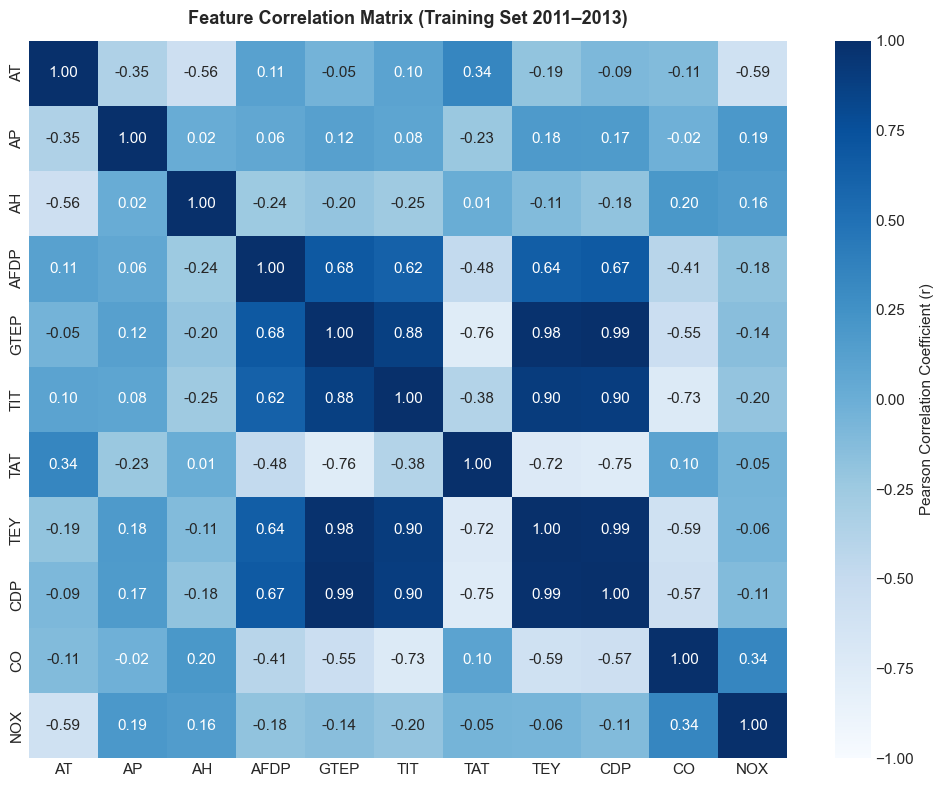

In [66]:
corr_matrix = train_df[sensor_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', vmin=-1, vmax=1,
            cbar_kws={'label': "Pearson Correlation Coefficient (r)"})
plt.title('Feature Correlation Matrix (Training Set 2011–2013)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### 3.4 Key Thermodynamic Relationships & Emissions Trade-offs

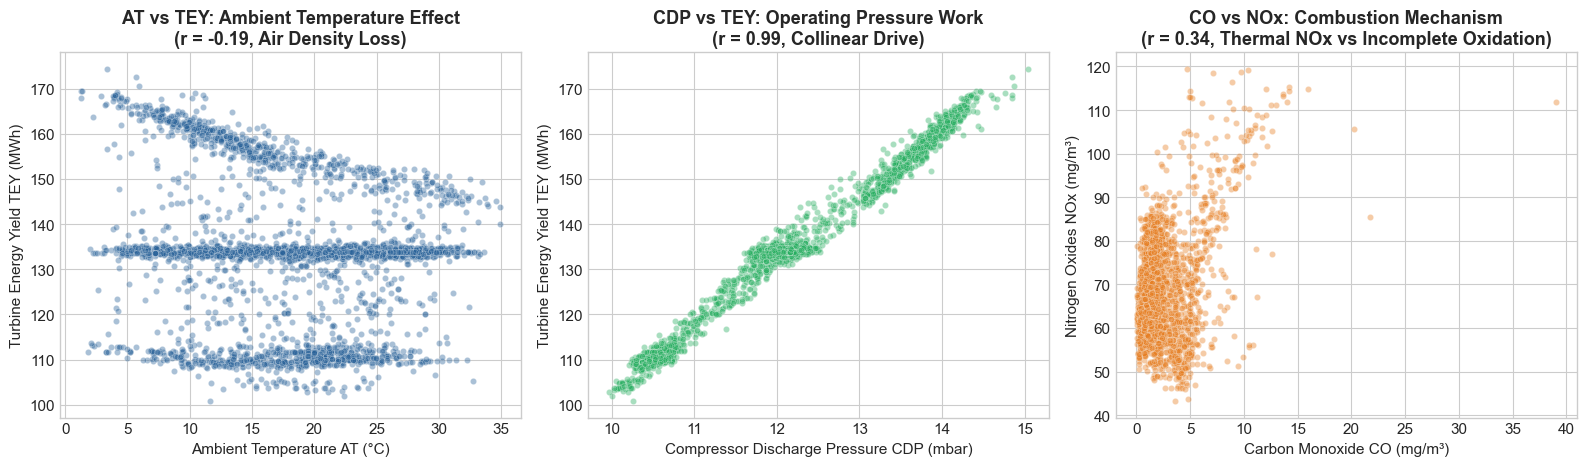

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
sample_df = train_df.sample(3000, random_state=42)

corr_at_tey = train_df[['AT', 'TEY']].corr().loc['AT', 'TEY']
corr_cdp_tey = train_df[['CDP', 'TEY']].corr().loc['CDP', 'TEY']
corr_co_nox = train_df[['CO', 'NOX']].corr().loc['CO', 'NOX']

# 1. Ambient Temperature vs Energy Yield
sns.scatterplot(data=sample_df, x='AT', y='TEY', ax=axes[0], color='#296299', alpha=0.4, s=20)
axes[0].set_title(f'AT vs TEY: Ambient Temperature Effect\n(r = {corr_at_tey:.2f}, Air Density Loss)', fontweight='bold')
axes[0].set_xlabel('Ambient Temperature AT (°C)')
axes[0].set_ylabel('Turbine Energy Yield TEY (MWh)')

# 2. Compressor Discharge Pressure vs Energy Yield
sns.scatterplot(data=sample_df, x='CDP', y='TEY', ax=axes[1], color='#27ae60', alpha=0.4, s=20)
axes[1].set_title(f'CDP vs TEY: Operating Pressure Work\n(r = {corr_cdp_tey:.2f}, Collinear Drive)', fontweight='bold')
axes[1].set_xlabel('Compressor Discharge Pressure CDP (mbar)')
axes[1].set_ylabel('Turbine Energy Yield TEY (MWh)')

# 3. CO vs NOx Tradeoff
sns.scatterplot(data=sample_df, x='CO', y='NOX', ax=axes[2], color='#e67e22', alpha=0.4, s=20)
axes[2].set_title(f'CO vs NOx: Combustion Mechanism\n(r = {corr_co_nox:.2f}, Thermal NOx vs Incomplete Oxidation)', fontweight='bold')
axes[2].set_xlabel('Carbon Monoxide CO (mg/m³)')
axes[2].set_ylabel('Nitrogen Oxides NOx (mg/m³)')

plt.tight_layout()
plt.show()

### 3.5 Multivariate Unsupervised EDA: Principal Component Analysis (PCA)

This PCA includes all standardized sensor measurements for descriptive exploratory analysis only. The target variables (`TEY`, `CO`, and `NOX`) are kept out of all predictive feature matrices used later.

Implementing PCA via Covariance Matrix Eigen-decomposition (**Slide 75 of `DA.pdf`**):
$$C = \frac{1}{m} X^T X \implies C v_i = \lambda_i v_i$$
$$\text{PVE}_i = \frac{\lambda_i}{\sum_{j=1}^n \lambda_j}$$

In [68]:
# Scaled training data for exploratory PCA
X_eda_std = train_scaled.values
eda_pca_cols = list(train_scaled.columns)

# Covariance matrix
C = np.cov(X_eda_std, rowvar=False)

# Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(C)

# Sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

pve = eigenvalues / np.sum(eigenvalues)
cum_pve = np.cumsum(pve)
n_components_eda = len(eigenvalues)

pca_summary = pd.DataFrame({
    'Component': [f'PC{i:02d}' for i in range(1, n_components_eda + 1)],
    'Eigenvalue (Variance)': eigenvalues.round(3),
    'Individual PVE (%)': (pve * 100).round(2),
    'Cumulative PVE (%)': (cum_pve * 100).round(2)
})
print(f"Components for 80% PVE: {np.argmax(cum_pve >= 0.80) + 1}")
print(f"Components for 90% PVE: {np.argmax(cum_pve >= 0.90) + 1}")
pca_summary

Components for 80% PVE: 4
Components for 90% PVE: 5


,Component,Eigenvalue (Variance),Individual PVE (%),Cumulative PVE (%)
0,PC01,5.310,48.28,48.28
1,PC02,2.253,20.48,68.76
2,PC03,0.971,8.82,77.58
3,PC04,0.866,7.87,85.45
4,PC05,0.722,6.57,92.02
5,PC06,0.458,4.16,96.18
6,PC07,0.288,2.62,98.80
7,PC08,0.126,1.14,99.94
8,PC09,0.003,0.03,99.97
9,PC10,0.002,0.02,99.99


### 3.6 PCA Scree Plot and Biplot Projection

The biplot displays the first two principal-component scores together with the corresponding eigenvector directions. The arrows are scaled only for visual readability; their directions, not their displayed lengths, represent the contribution of each standardized variable. This PCA is descriptive and includes all standardized sensor measurements, while the predictive models later use only the eight predictor features.

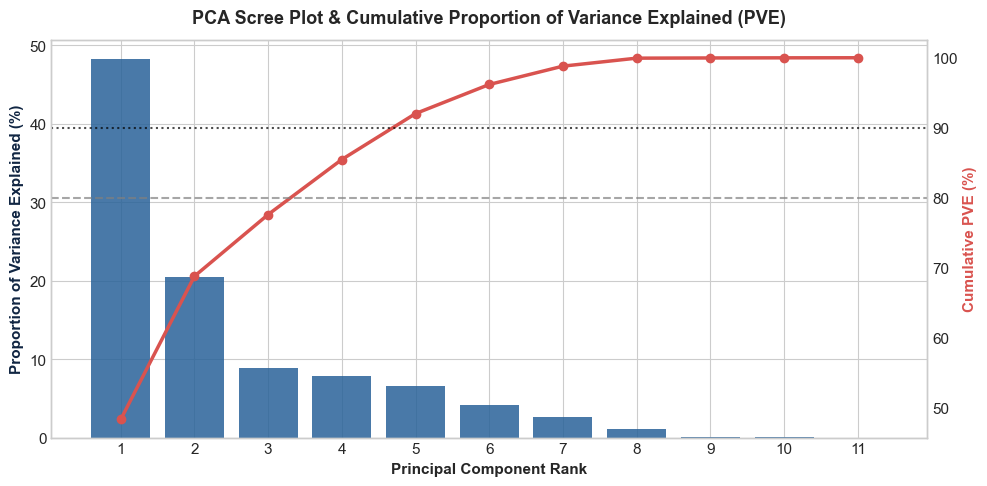

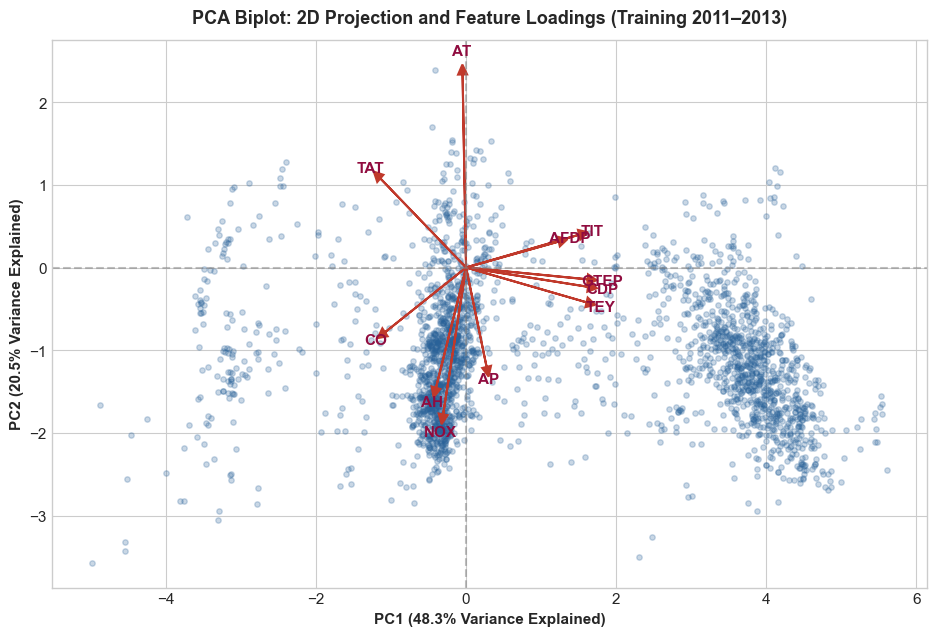

In [69]:
# Scree Plot
component_numbers = np.arange(1, n_components_eda + 1)
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(component_numbers, pve * 100, color='#296299', alpha=0.85, label='Individual PVE (%)')
ax1.set_xlabel('Principal Component Rank', fontweight='bold')
ax1.set_ylabel('Proportion of Variance Explained (%)', color='#102542', fontweight='bold')
ax1.set_xticks(component_numbers)

ax2 = ax1.twinx()
ax2.plot(component_numbers, cum_pve * 100, color='#d9534f', marker='o', linewidth=2.5, label='Cumulative PVE (%)')
ax2.set_ylabel('Cumulative PVE (%)', color='#d9534f', fontweight='bold')
ax2.grid(False)
ax2.axhline(80, color='gray', linestyle='--', alpha=0.7, label='80% Cutoff')
ax2.axhline(90, color='black', linestyle=':', alpha=0.7, label='90% Cutoff')

plt.title('PCA Scree Plot & Cumulative Proportion of Variance Explained (PVE)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# 2D Biplot
scores_2d = X_eda_std @ eigenvectors[:, :2]
plt.figure(figsize=(9.5, 6.5))
plt.scatter(scores_2d[:2500, 0], scores_2d[:2500, 1], alpha=0.25, color='#296299', s=15, label='Observations')

scale_arrow = 3.8
for i, var in enumerate(eda_pca_cols):
    plt.arrow(0, 0, eigenvectors[i, 0]*scale_arrow, eigenvectors[i, 1]*scale_arrow,
              head_width=0.12, head_length=0.12, fc='#c0392b', ec='#c0392b', linewidth=1.5)
    plt.text(eigenvectors[i, 0]*scale_arrow*1.12, eigenvectors[i, 1]*scale_arrow*1.12, var,
             color='#900C3F', fontweight='bold', fontsize=11, ha='center', va='center')

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel(f'PC1 ({pve[0]*100:.1f}% Variance Explained)', fontweight='bold')
plt.ylabel(f'PC2 ({pve[1]*100:.1f}% Variance Explained)', fontweight='bold')
plt.title('PCA Biplot: 2D Projection and Feature Loadings (Training 2011–2013)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 4. Main Analysis: Objectives & Methods Adopted

### 4.1 Objectives Formulation
Based on the course curriculum and industrial objectives, the analysis is organized into three primary modeling goals:
1. **Objective 1 — Turbine Energy Yield (TEY) Prediction & Multicollinearity Resolution**:
   - Predict net electrical output from ambient and operating telemetry.
   - Diagnose extreme multicollinearity via **Variance Inflation Factor (VIF, Slide 115)**.
   - Overcome coefficient variance inflation using **Principal Component Regression (PCR, Slides 70, 106)**.
2. **Objective 2 — Flue Gas Emissions Modeling (CO & NOx)**:
   - Quantify pollutant concentration dynamics under changing operational and environmental conditions.
   - Apply **Polynomial Regression (Slide 116 & Exercise 4.1)** to model non-linear low-load CO spikes ($x \to [x, x^2]$) while preserving convex linear training.
3. **Objective 3 — Operational Regime Discovery (Unsupervised Clustering)**:
   - Partition the turbine operational space into distinct dispatch states via **K-Means Clustering (Slides 90–91)**.
   - Validate cluster cohesion and separation using the **Silhouette Coefficient (Slide 94 & Exercise 3.1)**.

### 4.2 Multicollinearity Diagnostics via Variance Inflation Factor (VIF)
As defined in **Slide 115 of `DA.pdf`**:
$$\text{VIF}(\hat{\beta}_j) = \frac{1}{1 - R^2_{x_j | x_{-j}}}$$
where $R^2_{x_j | x_{-j}}$ is the coefficient of determination obtained by regressing feature $x_j$ on all remaining predictors. A $\text{VIF} > 10$ indicates severe multicollinearity.

In [70]:
# VIF uses only the eight predictor features
X_tr_std = train_features_std.values

vif_list = []
for j, col in enumerate(feature_cols):
    y_j = X_tr_std[:, j]
    X_other = np.delete(X_tr_std, j, axis=1)
    X_other_const = np.column_stack([np.ones(len(X_other)), X_other])
    
    beta_j = np.linalg.lstsq(X_other_const, y_j, rcond=None)[0]
    pred_j = X_other_const @ beta_j
    
    rss_j = np.sum((y_j - pred_j)**2)
    tss_j = np.sum((y_j - np.mean(y_j))**2)
    r2_j = 1 - rss_j / tss_j
    vif = 1 / (1 - r2_j)
    
    vif_list.append({
        'Predictor Feature': col,
        'R2 with Other Predictors': round(r2_j, 4),
        'VIF Score': round(vif, 2),
        'Collinearity Assessment': 'Severe Multicollinearity (VIF > 10)' if vif > 10 else 'Low / Acceptable'
    })

df_vif = pd.DataFrame(vif_list)
df_vif

,Predictor Feature,R2 with Other Predictors,VIF Score,Collinearity Assessment
0,AT,0.6716,3.04,Low / Acceptable
1,AP,0.3189,1.47,Low / Acceptable
2,AH,0.4137,1.71,Low / Acceptable
3,AFDP,0.4881,1.95,Low / Acceptable
4,GTEP,0.9962,260.47,Severe Multicollinearity (VIF > 10)
5,TIT,0.9962,262.12,Severe Multicollinearity (VIF > 10)
6,TAT,0.9925,133.21,Severe Multicollinearity (VIF > 10)
7,CDP,0.9971,342.82,Severe Multicollinearity (VIF > 10)


### 4.3 Mathematical Formulation of Regression Methods (OLS, PCR, Polynomial)
- **Multiple Linear Regression (Slide 106):**  
  $$\hat{\beta} = (X^T X)^{-1} X^T y$$
  The implementation uses `np.linalg.lstsq` instead of explicitly computing $(X^T X)^{-1}$ because least squares is numerically more stable, especially when predictors are highly correlated.
- **Principal Component Regression (Slides 70, 75):**  
  $$Z = X_{\text{std}} V_p, \quad \hat{\beta}_{\text{PCR}} = (Z^T Z)^{-1} Z^T y$$
- **Accuracy Metrics (Slide 108):**  
  $$R^2 = 1 - \frac{\text{RSS}}{\text{TSS}}, \quad \text{RMSE} = \sqrt{\frac{1}{m}\sum_{i=1}^m (y_i - \hat{y}_i)^2}$$

In [71]:
def fit_linear_model(X_train_data, y_train_data, X_test_data, y_test_data):
    # Add intercept column (Slide 104, 106)
    X_tr_c = np.column_stack([np.ones(len(X_train_data)), X_train_data])
    X_te_c = np.column_stack([np.ones(len(X_test_data)), X_test_data])
    
    beta = np.linalg.lstsq(X_tr_c, y_train_data, rcond=None)[0]
    
    y_tr_pred = X_tr_c @ beta
    r2_tr = 1 - np.sum((y_train_data - y_tr_pred)**2) / np.sum((y_train_data - np.mean(y_train_data))**2)
    rmse_tr = np.sqrt(np.mean((y_train_data - y_tr_pred)**2))
    
    y_te_pred = X_te_c @ beta
    r2_te = 1 - np.sum((y_test_data - y_te_pred)**2) / np.sum((y_test_data - np.mean(y_test_data))**2)
    rmse_te = np.sqrt(np.mean((y_test_data - y_te_pred)**2))
    
    return beta, (r2_tr, rmse_tr), (r2_te, rmse_te), y_te_pred

print("Regression modeling engine defined.")

Regression modeling engine defined.


In [72]:
def regression_metrics(y_true, y_pred):
    rss = np.sum((y_true - y_pred) ** 2)
    tss = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - rss / tss, np.sqrt(np.mean((y_true - y_pred) ** 2))

X_train_features = train_features_std.values
X_test_features = test_features_std.values
model_results = []
model_predictions = {}

# OLS for TEY
_, tey_train_metrics, tey_test_metrics, tey_test_pred = fit_linear_model(
    X_train_features, train_df['TEY'].values,
    X_test_features, test_df['TEY'].values
)
model_results.append({'Target': 'TEY', 'Model': 'OLS',
                      'Train R2': tey_train_metrics[0], 'Train RMSE': tey_train_metrics[1],
                      'Test R2': tey_test_metrics[0], 'Test RMSE': tey_test_metrics[1]})
model_predictions['TEY OLS'] = tey_test_pred

# Feature-only PCA for PCR
feature_covariance = np.cov(X_train_features, rowvar=False)
feature_eigenvalues, feature_eigenvectors = np.linalg.eigh(feature_covariance)
feature_order = np.argsort(feature_eigenvalues)[::-1]
feature_eigenvalues = feature_eigenvalues[feature_order]
feature_eigenvectors = feature_eigenvectors[:, feature_order]
feature_pve = feature_eigenvalues / np.sum(feature_eigenvalues)
feature_cumulative_pve = np.cumsum(feature_pve)
n_pcr = int(np.argmax(feature_cumulative_pve >= 0.90) + 1)

Z_train = X_train_features @ feature_eigenvectors[:, :n_pcr]
Z_test = X_test_features @ feature_eigenvectors[:, :n_pcr]
_, pcr_train_metrics, pcr_test_metrics, pcr_test_pred = fit_linear_model(
    Z_train, train_df['TEY'].values,
    Z_test, test_df['TEY'].values
)
model_results.append({'Target': 'TEY', 'Model': f'PCR ({n_pcr} PCs)',
                      'Train R2': pcr_train_metrics[0], 'Train RMSE': pcr_train_metrics[1],
                      'Test R2': pcr_test_metrics[0], 'Test RMSE': pcr_test_metrics[1]})
model_predictions['TEY PCR'] = pcr_test_pred

# Second-degree polynomial regression for CO
X_train_co = np.column_stack([X_train_features, X_train_features ** 2])
X_test_co = np.column_stack([X_test_features, X_test_features ** 2])
_, co_train_metrics, co_test_metrics, co_test_pred = fit_linear_model(
    X_train_co, train_df['CO'].values,
    X_test_co, test_df['CO'].values
)
model_results.append({'Target': 'CO', 'Model': 'Polynomial degree 2',
                      'Train R2': co_train_metrics[0], 'Train RMSE': co_train_metrics[1],
                      'Test R2': co_test_metrics[0], 'Test RMSE': co_test_metrics[1]})
model_predictions['CO polynomial'] = co_test_pred

# Multivariate linear regression for NOX
_, nox_train_metrics, nox_test_metrics, nox_test_pred = fit_linear_model(
    X_train_features, train_df['NOX'].values,
    X_test_features, test_df['NOX'].values
)
model_results.append({'Target': 'NOX', 'Model': 'OLS',
                      'Train R2': nox_train_metrics[0], 'Train RMSE': nox_train_metrics[1],
                      'Test R2': nox_test_metrics[0], 'Test RMSE': nox_test_metrics[1]})
model_predictions['NOX OLS'] = nox_test_pred

# Mean-prediction baseline for each target
for target in target_cols:
    baseline_pred = np.full(len(test_df), train_df[target].mean())
    baseline_train = np.full(len(train_df), train_df[target].mean())
    baseline_train_metrics = regression_metrics(train_df[target].values, baseline_train)
    baseline_test_metrics = regression_metrics(test_df[target].values, baseline_pred)
    model_results.append({'Target': target, 'Model': 'Training-mean baseline',
                          'Train R2': baseline_train_metrics[0], 'Train RMSE': baseline_train_metrics[1],
                          'Test R2': baseline_test_metrics[0], 'Test RMSE': baseline_test_metrics[1]})

df_model_results = pd.DataFrame(model_results).round(4)
print(f"PCR components retained: {n_pcr} ({feature_cumulative_pve[n_pcr - 1] * 100:.2f}% cumulative PVE)")
df_model_results

PCR components retained: 4 (90.76% cumulative PVE)


,Target,Model,Train R2,Train RMSE,Test R2,Test RMSE
0,TEY,OLS,0.9977,0.7618,0.9501,3.3456
1,TEY,PCR (4 PCs),0.9693,2.8095,0.9397,3.6774
2,CO,Polynomial degree 2,0.6477,1.3626,0.2635,1.8793
3,NOX,OLS,0.4536,8.1574,-1.0928,15.3006
4,TEY,Training-mean baseline,0.0000,16.0257,-0.0000,14.9777
5,CO,Training-mean baseline,0.0000,2.2957,-0.0333,2.2260
6,NOX,Training-mean baseline,0.0000,11.0360,-0.6914,13.7551


### 4.4 Unsupervised Operational Regime Discovery via K-Means and Silhouette
Implementing K-Means and Silhouette Coefficient from **Slides 90–94 & Exercise 3.1**:
$$\text{SIL}_i = \frac{b_i - a_i}{\max(a_i, b_i)}, \quad \text{SIL} = \frac{1}{m}\sum_{i=1}^m \text{SIL}_i$$

Candidate values of $K$ are compared using the silhouette coefficient. We retain $K=3$ to obtain three interpretable operating regimes, as required by the project objective. The silhouette value for the selected solution is reported alongside the comparison rather than presented as the absolute optimum.

In [73]:
def run_kmeans(X, k=3, max_iter=50, random_state=42):
    rng = np.random.default_rng(random_state)
    centroids = X[rng.choice(len(X), k, replace=False)]
    for _ in range(max_iter):
        dists = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(dists, axis=1)
        new_centroids = np.array([X[labels == j].mean(axis=0) if np.sum(labels == j) > 0 else centroids[j] for j in range(k)])
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return labels, centroids

def compute_silhouette(X, labels, sample_size=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    actual_sample_size = min(sample_size, len(X))
    idx = rng.choice(len(X), actual_sample_size, replace=False)
    X_sub = X[idx]
    lab_sub = labels[idx]
    unique_labels = np.unique(lab_sub)

    sil_values = []
    for i in range(len(X_sub)):
        c_i = lab_sub[i]
        same_cluster_pts = X_sub[lab_sub == c_i]
        same_cluster_distances = np.linalg.norm(same_cluster_pts - X_sub[i], axis=1)
        a_i = np.sum(same_cluster_distances) / (len(same_cluster_pts) - 1) if len(same_cluster_pts) > 1 else 0

        other_cluster_means = []
        for c in unique_labels:
            if c != c_i:
                other_pts = X_sub[lab_sub == c]
                if len(other_pts) > 0:
                    other_cluster_means.append(np.mean(np.linalg.norm(other_pts - X_sub[i], axis=1)))
        b_i = min(other_cluster_means) if other_cluster_means else 0
        sil_i = (b_i - a_i) / max(a_i, b_i) if max(a_i, b_i) > 0 else 0
        sil_values.append(sil_i)
    return np.mean(sil_values)

# Evaluate candidate K values using only standardized predictor features
k_scores = {}
for k in [2, 3, 4, 5]:
    labs, _ = run_kmeans(train_features_std.values, k=k)
    sil = compute_silhouette(train_features_std.values, labs)
    k_scores[k] = sil
    print(f"K = {k}: Mean Silhouette Coefficient = {sil:.4f}")

# K=3 is retained for three interpretable operating regimes
selected_k = 3
labels_k3, _ = run_kmeans(train_features_std.values, k=selected_k)
train_df_clusters = train_df.copy()
train_df_clusters['Operational_Regime'] = labels_k3
regime_profile = train_df_clusters.groupby('Operational_Regime')[['TEY', 'TIT', 'CDP', 'AT', 'CO', 'NOX']].mean().round(2)
regime_profile['Hours (Count)'] = train_df_clusters['Operational_Regime'].value_counts()

regime_names = {0: 'Peak Load', 1: 'Nominal Load', 2: 'Part Load'}
regime_profile.insert(0, 'Regime Name', regime_profile.index.map(regime_names))
print(f"Selected K for operational profiling: {selected_k}")
print(f"Silhouette for selected K: {k_scores[selected_k]:.4f}")
regime_profile

K = 2: Mean Silhouette Coefficient = 0.3763
K = 3: Mean Silhouette Coefficient = 0.3023
K = 4: Mean Silhouette Coefficient = 0.3216
K = 5: Mean Silhouette Coefficient = 0.2944
Selected K for operational profiling: 3
Silhouette for selected K: 0.3023


,Regime Name,TEY,TIT,CDP,AT,CO,NOX,Hours (Count)
Operational_Regime,,,,,,,,
0,Peak Load,158.16,1099.61,13.8,13.14,1.00,67.72,4309
1,Nominal Load,134.45,1090.73,12.2,24.50,1.48,65.04,7820
2,Part Load,122.28,1070.06,11.2,14.39,3.30,72.13,10062


## 5. Preview / Summary of Results

This section summarizes the predictive-model performance and the unsupervised clustering outcome. Detailed residual diagnostics and final conclusions are reserved for the presentation.

In [74]:
summary_table = df_model_results.copy()
summary_table['Train R2'] = summary_table['Train R2'].round(3)
summary_table['Test R2'] = summary_table['Test R2'].round(3)
summary_table['Train RMSE'] = summary_table['Train RMSE'].round(2)
summary_table['Test RMSE'] = summary_table['Test RMSE'].round(2)

print("=== Predictive Model Summary ===")
display(summary_table)
print(f"\nSelected clustering K: {selected_k}")
print(f"Selected clustering silhouette: {k_scores[selected_k]:.4f}")

=== Predictive Model Summary ===


,Target,Model,Train R2,Train RMSE,Test R2,Test RMSE
0,TEY,OLS,0.998,0.76,0.950,3.35
1,TEY,PCR (4 PCs),0.969,2.81,0.940,3.68
2,CO,Polynomial degree 2,0.648,1.36,0.264,1.88
3,NOX,OLS,0.454,8.16,-1.093,15.30
4,TEY,Training-mean baseline,0.000,16.03,-0.000,14.98
5,CO,Training-mean baseline,0.000,2.30,-0.033,2.23
6,NOX,Training-mean baseline,0.000,11.04,-0.691,13.76



Selected clustering K: 3
Selected clustering silhouette: 0.3023
